In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.select_dtypes(include="str").columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')

In [4]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [5]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

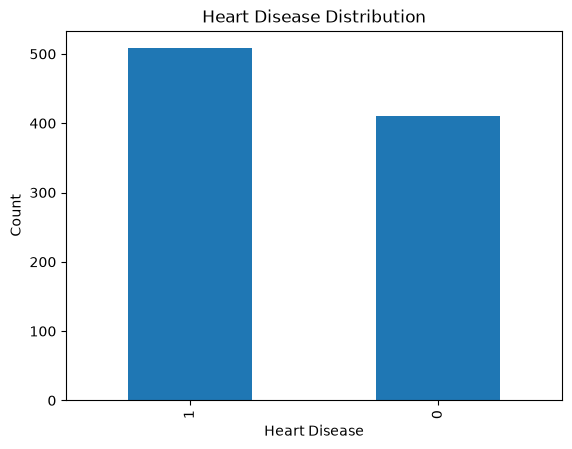

In [10]:
df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

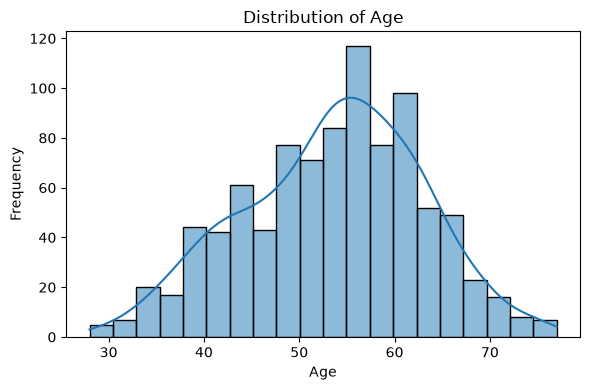

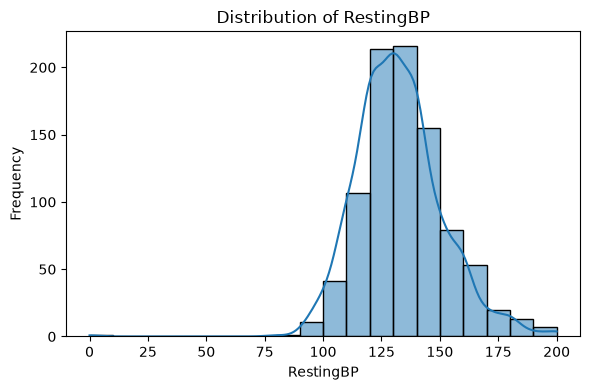

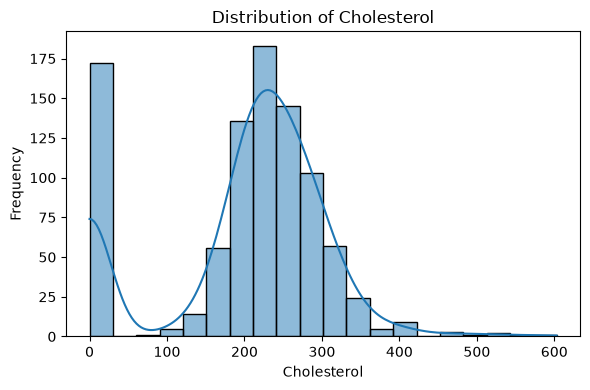

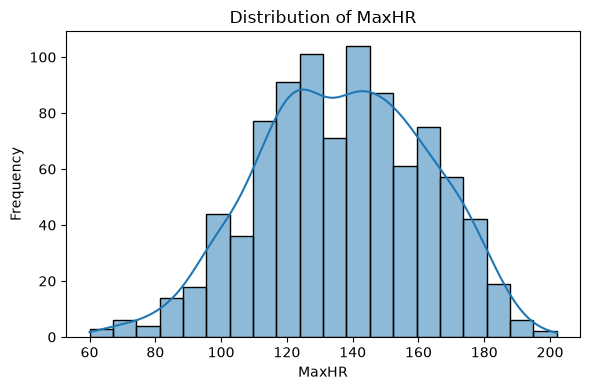

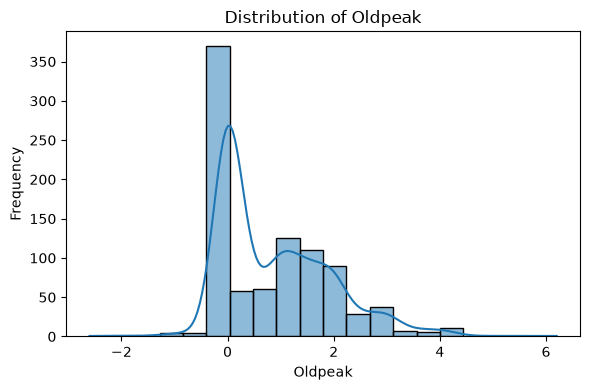

In [27]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

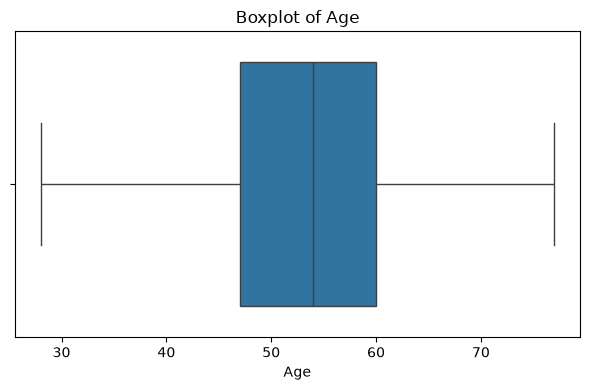

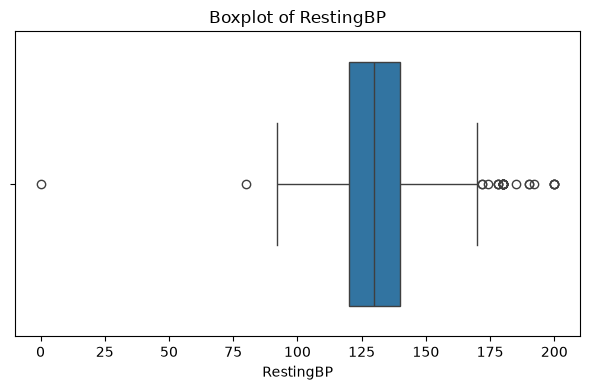

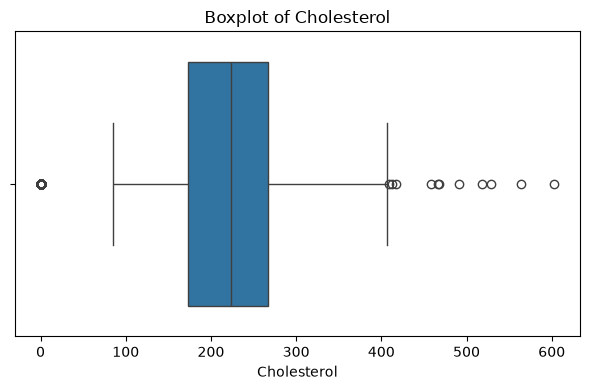

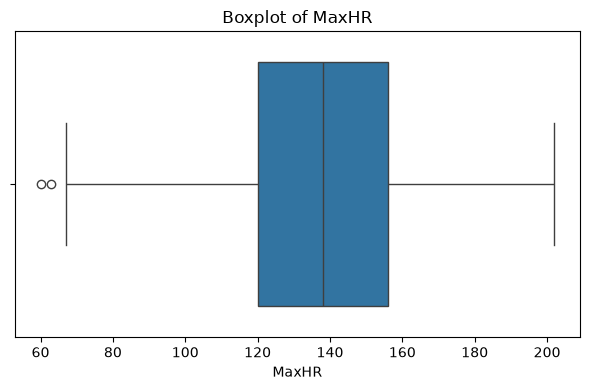

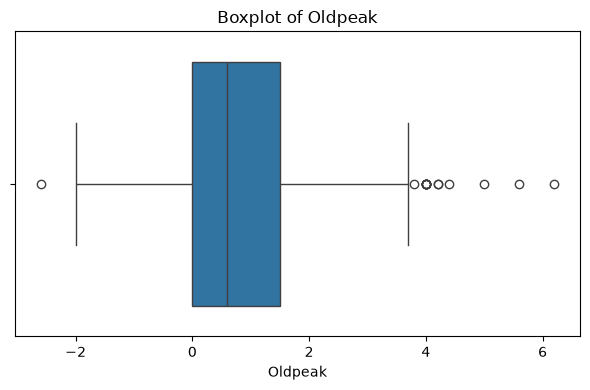

In [ ]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [15]:
df["RestingBP"].min(), df["RestingBP"].max()

(np.int64(0), np.int64(200))

In [16]:
(df["RestingBP"] == 0).sum()

np.int64(1)

In [17]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

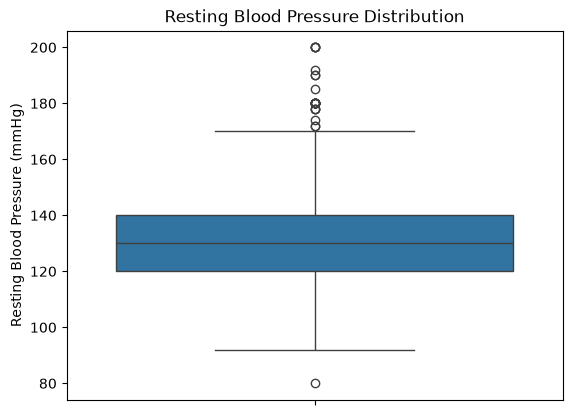

In [18]:
sns.boxplot(
    data=df,
    y="RestingBP"
)

plt.title("Resting Blood Pressure Distribution")
plt.ylabel("Resting Blood Pressure (mmHg)")
plt.show()

### Handling Outliers in Oldpeak

In [19]:
df["Oldpeak"].min(), df["Oldpeak"].max()

(np.float64(-2.6), np.float64(6.2))

In [54]:
df["Oldpeak"].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

### Handling Outliers in Oldpeak

The `Oldpeak` feature contains some extreme values, with values ranging from -2.6 to 6.2. The upper values may appear as statistical outliers based on the boxplot and distribution.

However, these observations were retained because extreme `Oldpeak` values may represent genuine clinical measurements rather than data-entry errors. Removing or clipping them could result in losing medically meaningful information that may help the model predict heart disease.

Therefore, no outlier treatment was applied to `Oldpeak`.


### Handling Outliers in MaxHR


In [20]:
df["MaxHR"].min(), df["MaxHR"].max()

(np.int64(60), np.int64(202))

In [21]:
df[df["MaxHR"] < 80][["Age", "MaxHR", "HeartDisease"]]

,Age,MaxHR,HeartDisease
318,61,77,1
360,62,72,1
370,60,63,1
390,51,60,1
399,61,70,1
402,65,67,1
407,62,72,1
410,62,78,1
496,58,69,0
550,55,73,1



The `MaxHR` feature contained some low values that were identified as statistical outliers in the boxplot. However, these values were not considered invalid because they fall within a possible physiological range and may represent genuine measurements from patients with cardiovascular conditions.

Since these observations may contain important information related to heart disease, they were retained and were not removed or clipped.

Therefore, no outlier treatment was applied to `MaxHR`.


### Handling Outliers in Cholesterol

The `Cholesterol` feature contained several zero values. Since a cholesterol level of 0 mg/dL is not a realistic value for a living person, these values were considered invalid/missing values rather than genuine outliers.

First, the number of zero values was checked:

```python
(df["Cholesterol"] == 0).sum()
```

There were 172 zero values. These values were replaced with `NaN`:

```python
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
```

After replacing the zero values, the boxplot was examined again to identify the remaining outliers.

The remaining high cholesterol values were not removed or clipped because they may represent genuine medical conditions rather than data-entry errors. Removing these values could result in losing important information about patients with unusually high cholesterol levels.

The missing values will be handled later during preprocessing using `SimpleImputer(strategy="median")`.


In [22]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

In [23]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

In [24]:
df["Cholesterol"].isna().sum()

np.int64(172)

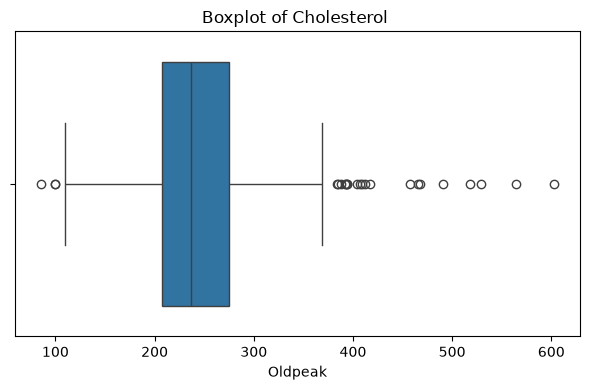

In [59]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Cholesterol"])

plt.title(f"Boxplot of Cholesterol ")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [25]:
df.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

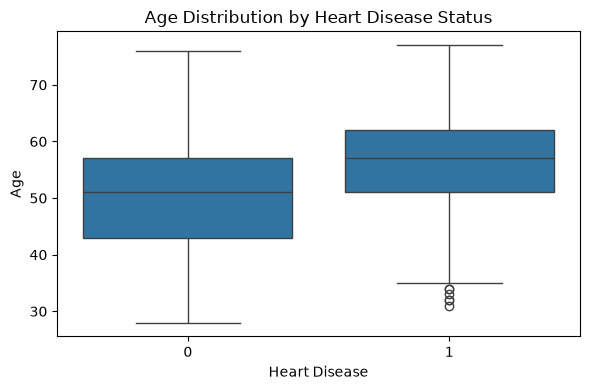

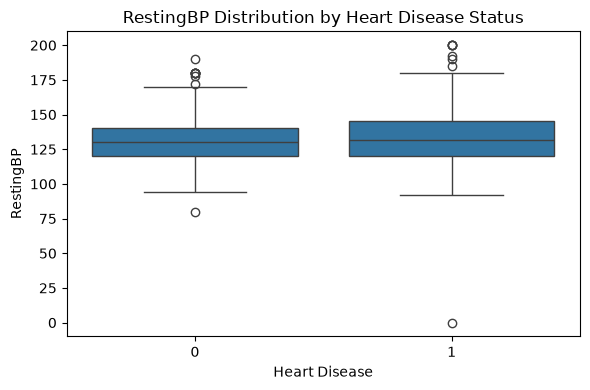

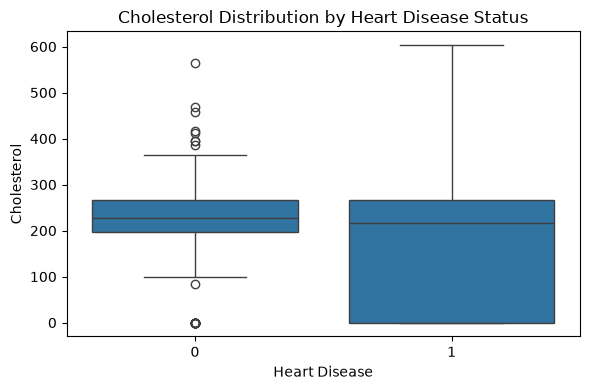

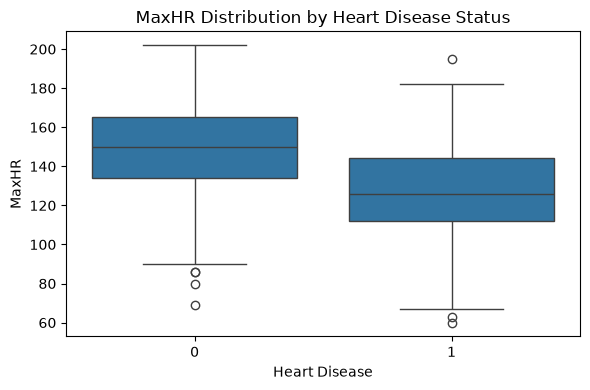

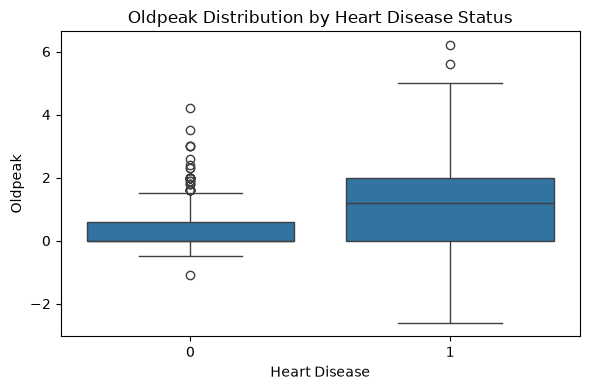

In [12]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=col
    )

    plt.title(f"{col} Distribution by Heart Disease Status")
    plt.xlabel("Heart Disease")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [13]:
df.groupby("HeartDisease")[numerical_features].mean()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
HeartDisease,,,,,
0,50.551220,130.180488,227.121951,148.151220,0.408049
1,55.899606,134.185039,175.940945,127.655512,1.274213


In [4]:
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [21]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


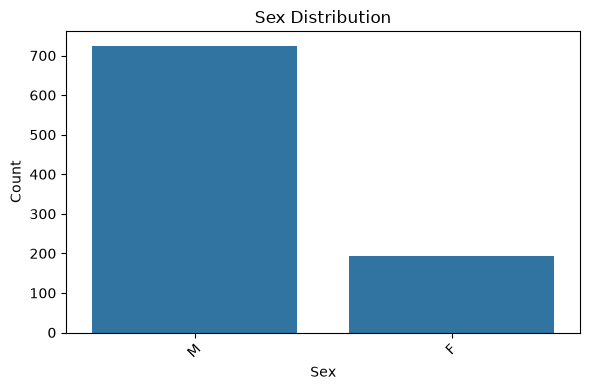

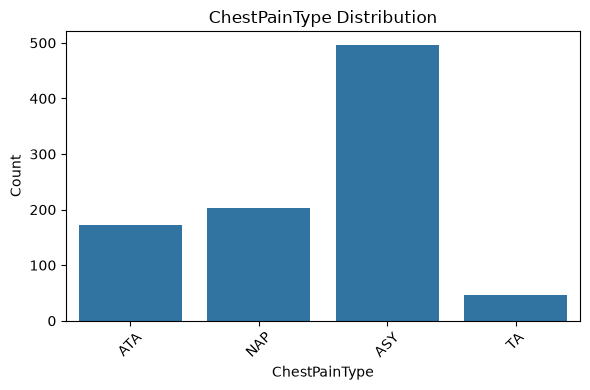

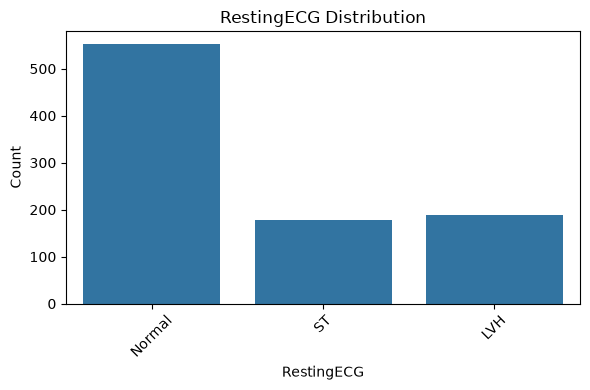

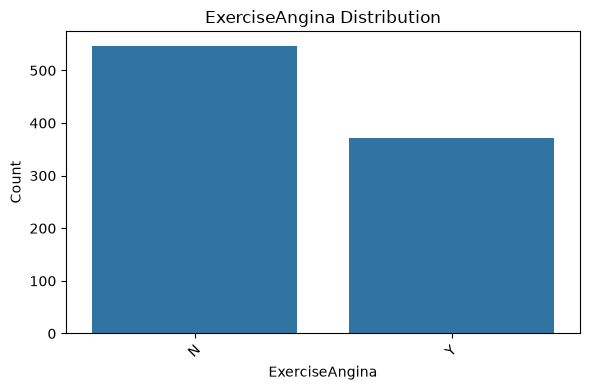

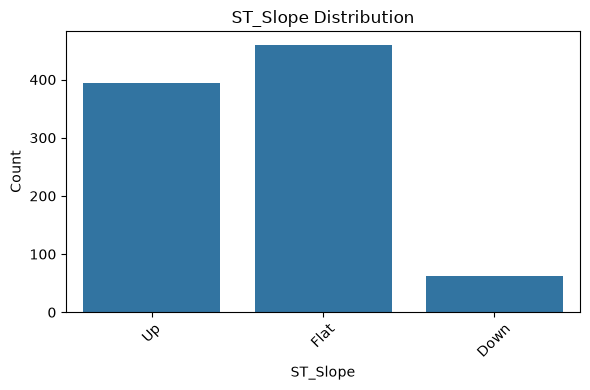

In [25]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))

    sns.countplot(data=df, x=col)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [31]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ChestPainType,,
ASY,20.967742,79.032258
ATA,86.127168,13.872832
NAP,64.532020,35.467980
TA,56.521739,43.478261


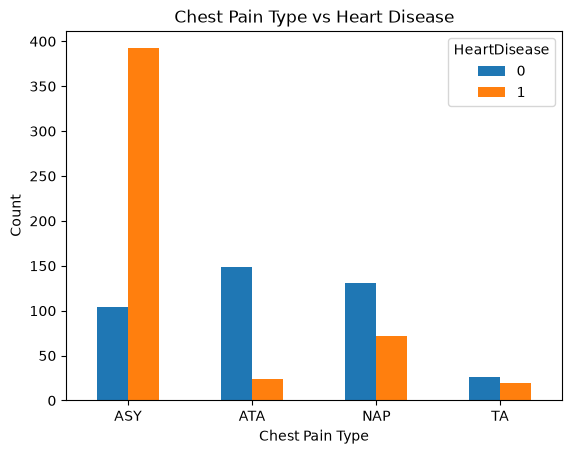

In [32]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [33]:
pd.crosstab(
    df["Sex"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
Sex,,
F,74.093264,25.906736
M,36.827586,63.172414


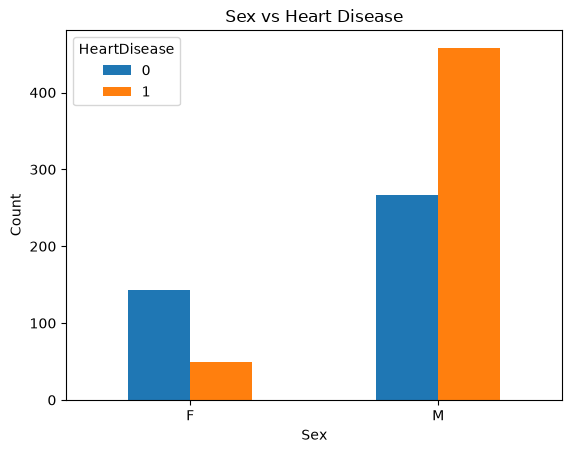

In [34]:
pd.crosstab(
    df["Sex"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [5]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ST_Slope,,
Down,22.222222,77.777778
Flat,17.173913,82.826087
Up,80.253165,19.746835


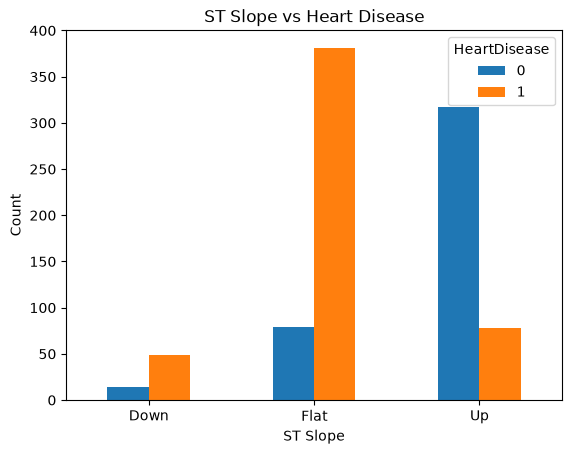

In [6]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("ST Slope vs Heart Disease")
plt.xlabel("ST Slope")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [7]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ExerciseAngina,,
N,64.899452,35.100548
Y,14.824798,85.175202


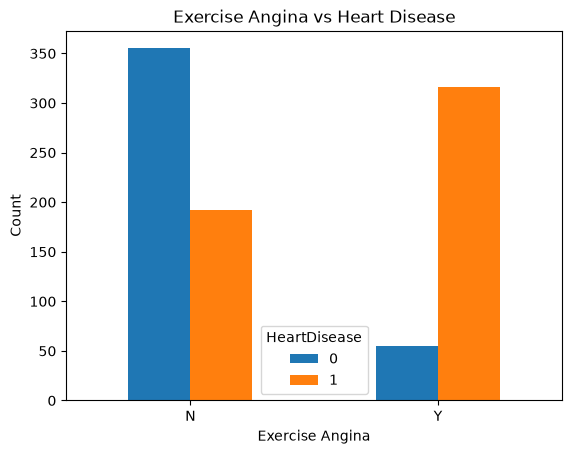

In [8]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Exercise Angina vs Heart Disease")
plt.xlabel("Exercise Angina")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
RestingECG,,
LVH,43.617021,56.382979
Normal,48.369565,51.630435
ST,34.269663,65.730337


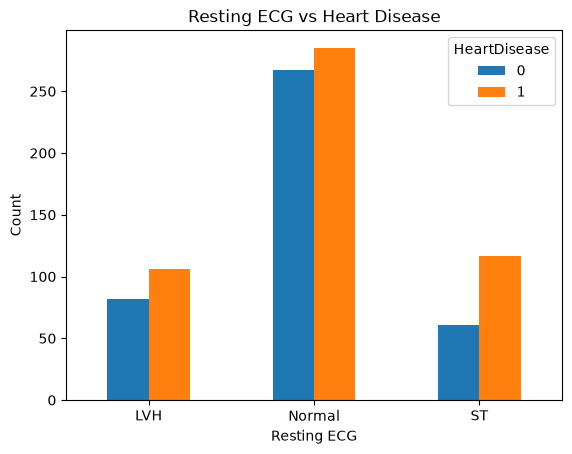

In [10]:
pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Resting ECG vs Heart Disease")
plt.xlabel("Resting ECG")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [38]:
corr = df.corr(numeric_only=True)

corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


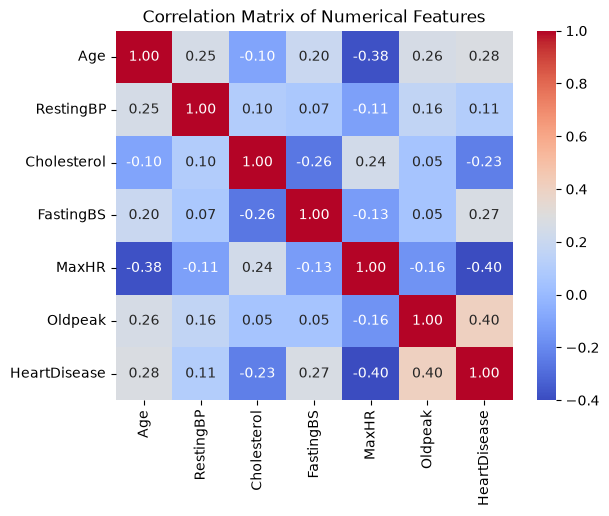

In [40]:
plt.Figure(figsize=(14,10))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")

plt.show()